# Challenge 1: datos y análisis exploratorio

Tu primera responsabilidad es preparar una fuente de datos confiable para el proyecto de clasificación de vinos.

**Entrada:** `data/raw/wine.csv`  
**Salidas:** `data/processed/train.csv`, `data/processed/test.csv` y `artifacts/data_contract.json`

> El conjunto de test se crea aquí, pero no debe explorarse ni utilizarse después del split.

## Objetivos

- cargar y validar datos externos;
- identificar problemas básicos de calidad;
- crear un split reproducible y estratificado;
- realizar EDA únicamente sobre entrenamiento;
- guardar datos y metadatos para la siguiente etapa.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

np.random.seed(42)
plt.rcParams["figure.figsize"] = (7, 4)

In [2]:
from pathlib import Path

PROJECT_DIR = Path.cwd()
RAW_DATA_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
REPORTS_DIR = PROJECT_DIR / "reports"

for directory in (PROCESSED_DATA_DIR, ARTIFACTS_DIR, REPORTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

## 1. Carga y profiling

In [3]:
DATA_PATH = RAW_DATA_DIR / "wine.csv"

df = pd.read_csv(DATA_PATH)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [4]:
print("Forma:", df.shape)
print("Duplicados:", df.duplicated().sum())
print("Valores faltantes:", int(df.isna().sum().sum()))
print("\nDistribución de target:")
display(df["target"].value_counts().sort_index().to_frame("n").assign(proporción=lambda t: (t["n"] / len(df)).round(3)))

profile = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "unique": df.nunique(),
    "min": df.min(numeric_only=True),
    "max": df.max(numeric_only=True),
})
profile

Forma: (178, 14)
Duplicados: 0
Valores faltantes: 0

Distribución de target:


,n,proporción
target,,
0,59,0.331
1,71,0.399
2,48,0.270


,dtype,missing,unique,min,max
alcohol,float64,0,126,11.03,14.83
malic_acid,float64,0,133,0.74,5.80
ash,float64,0,79,1.36,3.23
alcalinity_of_ash,float64,0,63,10.60,30.00
magnesium,float64,0,53,70.00,162.00
total_phenols,float64,0,97,0.98,3.88
flavanoids,float64,0,132,0.34,5.08
nonflavanoid_phenols,float64,0,39,0.13,0.66
proanthocyanins,float64,0,101,0.41,3.58
color_intensity,float64,0,132,1.28,13.00


**Conclusión de calidad:**

> El archivo tiene 178 filas, 13 variables numéricas (`float64`) y la columna `target` (`int64`) con tres clases: 0 = 59, 1 = 71, 2 = 48 vinos. No hay valores faltantes ni filas duplicadas, por lo que **no se elimina ni se imputa nada**. Las clases están moderadamente desbalanceadas (la clase 2 representa el 27 %), así que el split debe ser estratificado. Las escalas son muy distintas (por ejemplo `proline` llega a 1680 y `hue` está cerca de 1); esto se resolverá con estandarización dentro del pipeline, no aquí.

## 2. Split train/test

In [5]:
TEST_SIZE = 0.20

train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    stratify=df["target"],
    random_state=RANDOM_STATE,
)

In [6]:
# Verificación del split
assert len(train_df) + len(test_df) == len(df)
assert set(train_df.index).isdisjoint(set(test_df.index))
print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (142, 14)
Test: (36, 14)


## 3. EDA sobre entrenamiento

Incluye:

- distribución de clases;
- distribuciones o boxplots de variables relevantes;
- correlaciones;
- tres hallazgos que puedan influir en el modelado.

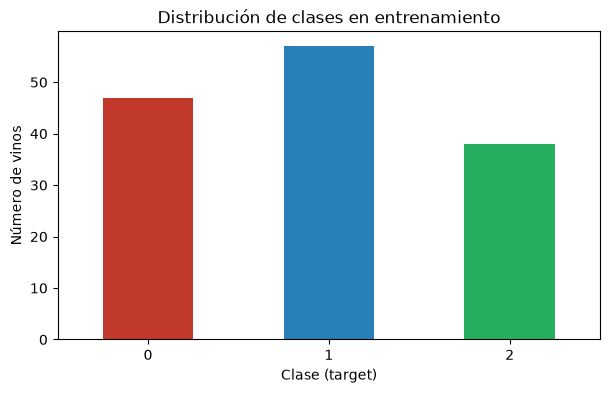

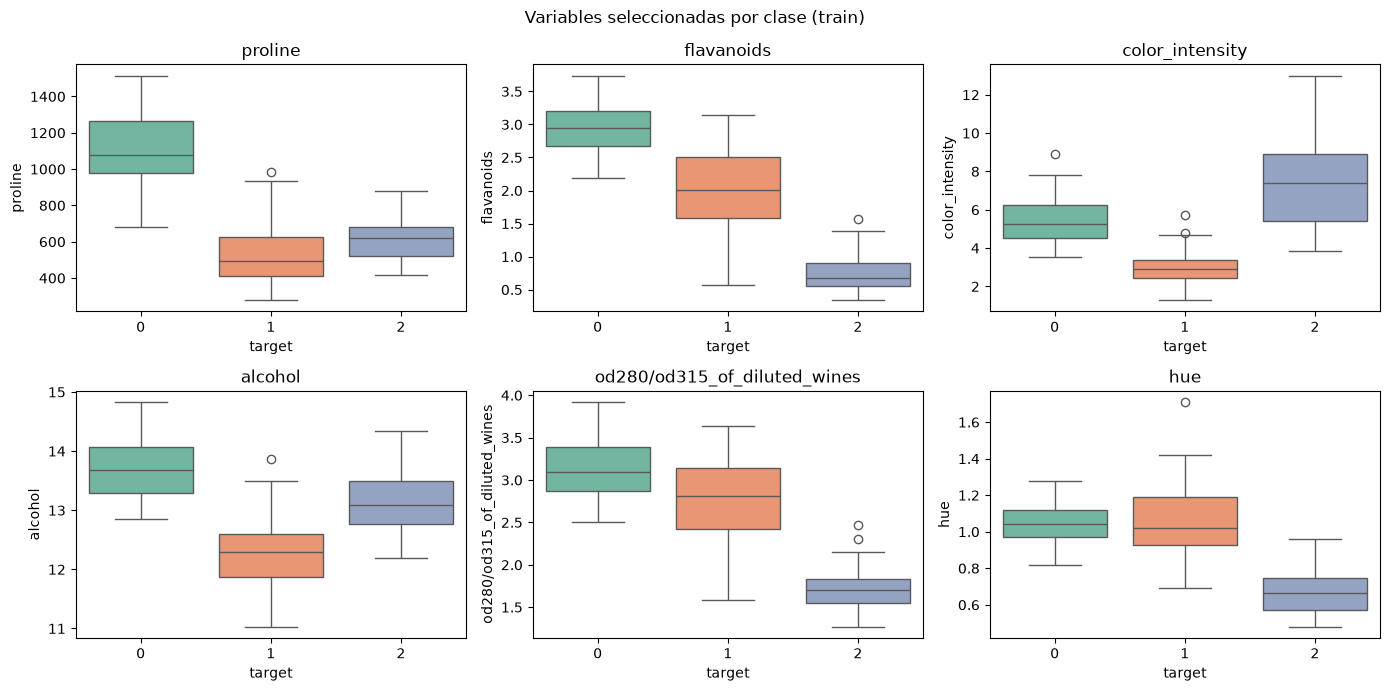

,mean,std,min,max
proline,739.48,301.50,278.00,1515.00
magnesium,99.63,14.94,70.00,162.00
alcalinity_of_ash,19.63,3.38,10.60,30.00
color_intensity,4.99,2.33,1.28,13.00
malic_acid,2.34,1.10,0.74,5.80
flavanoids,1.99,0.95,0.34,3.74
alcohol,12.97,0.80,11.03,14.83
od280/od315_of_diluted_wines,2.61,0.69,1.27,3.92
total_phenols,2.27,0.62,0.98,3.88
proanthocyanins,1.60,0.58,0.42,3.58


In [7]:
target = "target"
features = [c for c in train_df.columns if c != target]

# 1. Distribución de clases (solo train)
ax = train_df[target].value_counts().sort_index().plot.bar(color=["#c0392b", "#2980b9", "#27ae60"])
ax.set_xlabel("Clase (target)")
ax.set_ylabel("Número de vinos")
ax.set_title("Distribución de clases en entrenamiento")
plt.xticks(rotation=0)
plt.show()

# 2. Boxplots por clase de variables relevantes
selected = ["proline", "flavanoids", "color_intensity", "alcohol", "od280/od315_of_diluted_wines", "hue"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), selected):
    sns.boxplot(data=train_df, x=target, y=col, hue=target, palette="Set2", legend=False, ax=ax)
    ax.set_title(col)
plt.suptitle("Variables seleccionadas por clase (train)")
plt.tight_layout()
plt.show()

# 3. Escalas de las variables
train_df[features].describe().T[["mean", "std", "min", "max"]].sort_values("std", ascending=False).round(2)

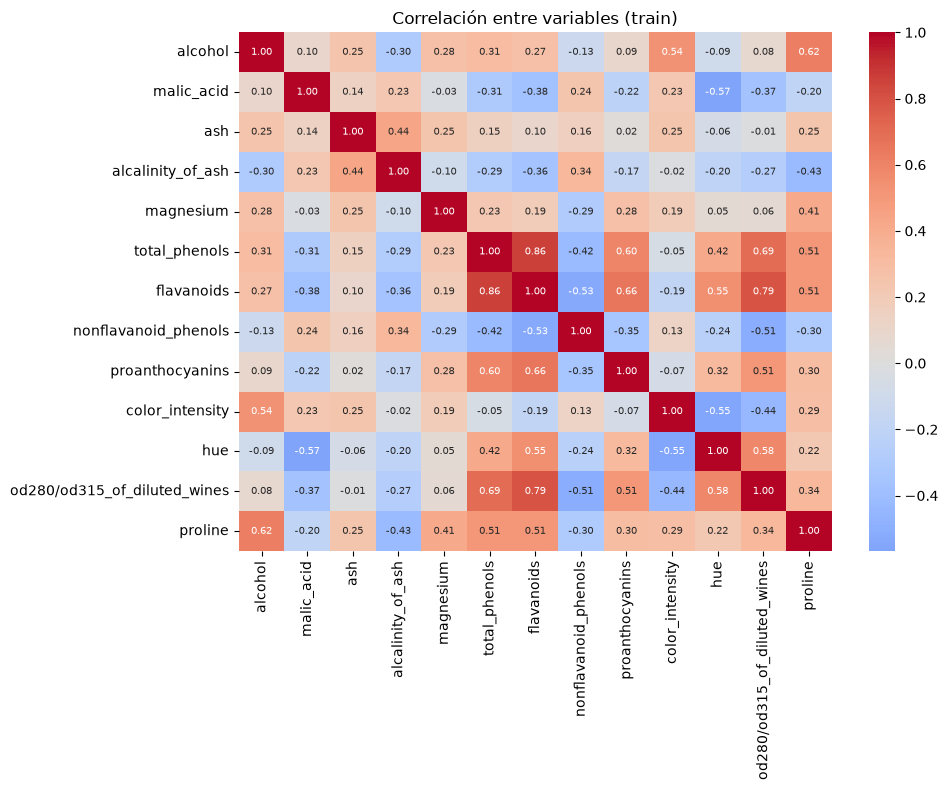

,proline,flavanoids,color_intensity,alcohol,od280/od315_of_diluted_wines,hue
target,,,,,,
0,1092.34,2.93,5.48,13.70,3.14,1.05
1,526.25,2.01,2.98,12.28,2.77,1.05
2,622.89,0.78,7.39,13.11,1.71,0.68


In [8]:
# 4. Correlaciones entre variables (train)
plt.figure(figsize=(10, 8))
sns.heatmap(train_df[features].corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f", annot_kws={"size": 7})
plt.title("Correlación entre variables (train)")
plt.tight_layout()
plt.show()

# 5. Medias por clase de las variables seleccionadas
train_df.groupby(target)[selected].mean().round(2)

**Hallazgos:** (calculados solo sobre `train_df`, 142 vinos)

1. **Hay variables que separan muy bien las clases.** `flavanoids` (medias 2.93 / 2.01 / 0.78 para las clases 0 / 1 / 2) y `od280/od315_of_diluted_wines` aíslan la clase 2; `proline` (≈1092 en la clase 0 frente a ≈526 y ≈623) aísla la clase 0. Se espera que incluso modelos simples logren accuracy alto.
2. **Las escalas difieren en varios órdenes de magnitud** (`proline` con std ≈ 301, `magnesium` ≈ 15, `hue` ≈ 0.23). LogReg y KNN deben llevar `StandardScaler`; el árbol no lo necesita.
3. **Hay multicolinealidad**: `total_phenols`–`flavanoids` (|r| = 0.86) y `flavanoids`–`od280/od315` (0.79). No impide entrenar, pero los coeficientes de la regresión logística deben interpretarse con cuidado y un árbol puede usar cualquiera de las variables correlacionadas indistintamente.

## 4. Persistencia de datos y contrato

In [9]:
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_df.to_csv(PROCESSED_DATA_DIR / "train.csv", index=False)
test_df.to_csv(PROCESSED_DATA_DIR / "test.csv", index=False)

contract = {
    "dataset": "Wine (UCI) — data/raw/wine.csv",
    "target": "target",
    "features": [c for c in train_df.columns if c != "target"],
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
}
(ARTIFACTS_DIR / "data_contract.json").write_text(json.dumps(contract, indent=2), encoding="utf-8")
print("Guardados:", PROCESSED_DATA_DIR / "train.csv", PROCESSED_DATA_DIR / "test.csv", ARTIFACTS_DIR / "data_contract.json")

Guardados: data/processed/train.csv data/processed/test.csv artifacts/data_contract.json


In [10]:
# Verificación de entrega
assert (PROCESSED_DATA_DIR / "train.csv").exists()
assert (PROCESSED_DATA_DIR / "test.csv").exists()
assert (ARTIFACTS_DIR / "data_contract.json").exists()
print("Challenge 1 completado.")

Challenge 1 completado.


## Checklist

- [x] Cargué el CSV desde `data/raw`.
- [x] Revisé calidad y distribución de la clase.
- [x] Realicé un split estratificado.
- [x] No exploré el conjunto de test.
- [x] Guardé los tres artefactos requeridos.